# Lista 03 de Visão Computacional

Beatriz Rodrigues Cavalcante - 22210505

Hugo Coêlho da Silva - 22111533

Link da lista: https://drive.google.com/file/d/1RLlDFoV_hk_BUscJiveLQ8e_TXUyxZl4/view


## Importações e Funções Auxiliares

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv
from cv2.typing import MatLike
from pathlib import Path


def show_images(
    *images: np.ndarray,
    titles: list[str] | None = None,
    columns: int = 2,
    scale: int = 5,
) -> None:
    num_images = len(images)

    if titles is None:
        titles = [f"Image {i + 1}" for i in range(num_images)]

    rows = (num_images + columns - 1) // columns

    fig, axes = plt.subplots(rows, columns, figsize=(scale * columns, scale * rows))
    axes = np.array(axes).reshape(rows, columns)

    for ax, img, title in zip(axes.flat, images, titles):
        ax.imshow(img, cmap="gray" if len(img.shape) == 2 else None)
        ax.set_title(title)

    for i in range(num_images, rows * columns):
        fig.delaxes(axes.flat[i])

    plt.tight_layout()

## Questão 1

Nesta questão, 


https://medium.com/@navekshasood/image-stitching-to-create-a-panorama-5e030ecc8f7
https://marcus888-techstack.github.io/introduction-to-opencv/modules/11-stitching



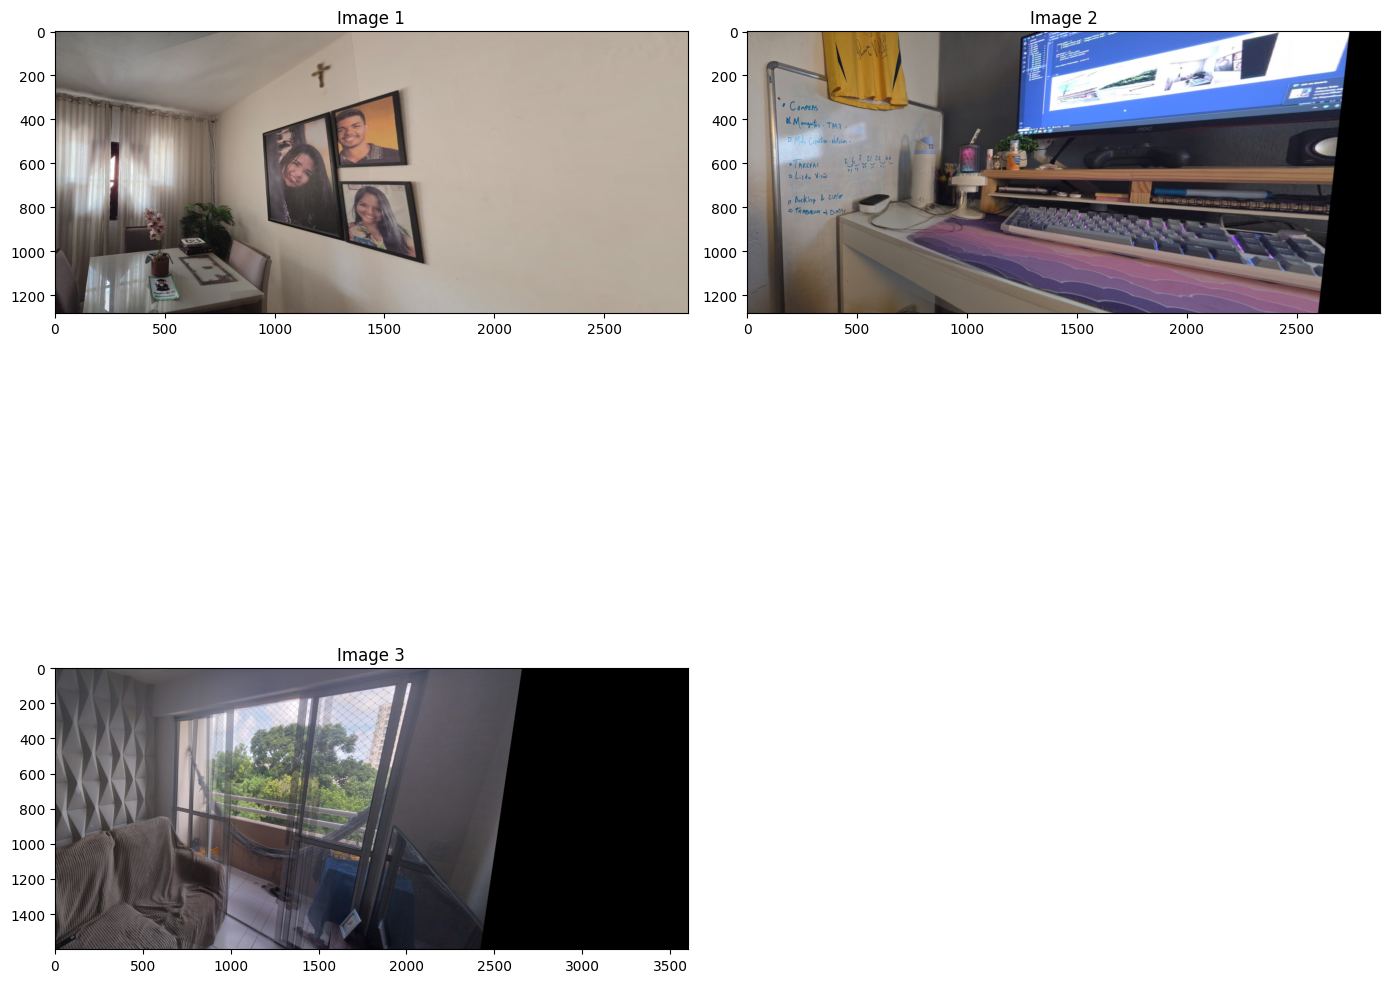

In [3]:
MIN_MATCH_COUNT = 5

# Adaptação da implementação trazida da terceira questão da lista 02
def stitch_images_to_panorama(
    left: MatLike,
    right: MatLike,
    blend_mode: str = "feather",
) -> MatLike:
    if left is None or right is None:
        raise FileNotFoundError(
            f"Could not load images {left} or {right}"
        )

    blend_mode = blend_mode.lower()
    if blend_mode not in {"feather", "alpha"}:
        raise ValueError("blend_mode must be 'feather' or 'alpha'")

    left_gray = cv.cvtColor(left, cv.COLOR_BGR2GRAY)
    right_gray = cv.cvtColor(right, cv.COLOR_BGR2GRAY)

    sift = cv.SIFT.create(nfeatures=1000)
    kp1, des1 = sift.detectAndCompute(left_gray, None)
    kp2, des2 = sift.detectAndCompute(right_gray, None)

    matches = cv.BFMatcher().knnMatch(des2, des1, k=2)

    good = []
    for m, n in matches:
        if m.distance < 0.7 * n.distance:
            good.append(m)

    if len(good) < MIN_MATCH_COUNT:
        raise Exception("Not enough matching points")

    pts_src = np.float32([kp2[m.queryIdx].pt for m in good]).reshape(-1, 1, 2)
    pts_dst = np.float32([kp1[m.trainIdx].pt for m in good]).reshape(-1, 1, 2)
    H, _ = cv.findHomography(pts_src, pts_dst, cv.RANSAC, 5.0)

    h_left, w_left = left.shape[:2]
    h_right, w_right = right.shape[:2]

    width = w_left + w_right
    height = max(h_left, h_right)

    warped = cv.warpPerspective(right, H, (width, height))

    result_roi = warped[0:h_left, 0:w_left]

    left_valid = np.any(left != 0, axis=2)
    result_valid = np.any(result_roi != 0, axis=2)
    overlap_region = left_valid & result_valid

    blended = result_roi.copy()

    if blend_mode == "alpha":
        if np.any(overlap_region):
            for c in range(3):
                blended[overlap_region, c] = (
                    0.5 * result_roi[overlap_region, c].astype(np.float32)
                    + 0.5 * left[overlap_region, c].astype(np.float32)
                ).astype(np.uint8)
        only_left = left_valid & ~result_valid
        blended[only_left] = left[only_left]
    else:
        if np.any(overlap_region):
            overlap_cols = np.where(np.any(overlap_region, axis=0))[0]
            if overlap_cols.size > 0:
                x0 = int(overlap_cols[0])
                x1 = int(overlap_cols[-1])
                feather_width = max(1, x1 - x0)

                alpha = np.zeros((h_left, w_left), dtype=np.float32)
                ramp = np.clip(
                    (np.arange(w_left, dtype=np.float32) - x0) / feather_width,
                    0.0,
                    1.0,
                )
                alpha[:, :] = ramp[None, :]

                alpha_3 = alpha[..., None]
                blended = (
                    alpha_3 * result_roi.astype(np.float32)
                    + (1.0 - alpha_3) * left.astype(np.float32)
                ).astype(np.uint8)

                only_left = left_valid & ~result_valid
                blended[only_left] = left[only_left]
                only_right = result_valid & ~left_valid
                blended[only_right] = result_roi[only_right]
        else:
            only_left = left_valid & ~result_valid
            blended[only_left] = left[only_left]

    warped[0:h_left, 0:w_left] = blended

    return warped


def gen_panorama(trio_path: list[str], blend_mode: str = "feather") -> MatLike:
    left = cv.imread(trio_path[0], cv.IMREAD_COLOR)
    if left is None:
        raise FileNotFoundError(f"Could not load image {trio_path[0]}")

    for img_path in trio_path[1:]:
        right = cv.imread(img_path, cv.IMREAD_COLOR)
        if right is None:
            raise FileNotFoundError(f"Could not load image {img_path}")
        left = stitch_images_to_panorama(left, right, blend_mode=blend_mode)

    return cv.cvtColor(left, cv.COLOR_BGR2RGB)


trios_path = [
    ["images/sala1.png", "images/sala2.png", "images/sala3.png"],
    ["images/quarto1.png", "images/quarto2.png", "images/quarto3.png"],
    ["images/sofa1.png", "images/sofa2.png", "images/sofa3.png"],
]

panoramas = []
for trio in trios_path:
    result = gen_panorama(trio, blend_mode="feather")
    panoramas.append(result)

show_images(*panoramas, scale=7)